# Classification and Visulization

## Custom Data

### Circle Data

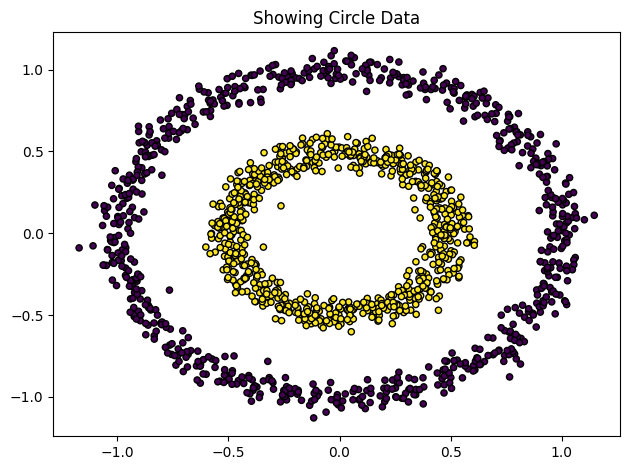

In [12]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

data = make_circles(n_samples=1500, factor=0.5, noise=0.05, random_state=44)
plt.scatter(data[0][:, 0], data[0][:, 1], c=data[1], edgecolors='k', cmap='viridis', s=20)
plt.title("Showing Circle Data")
plt.tight_layout()
plt.show()

### Blob Data

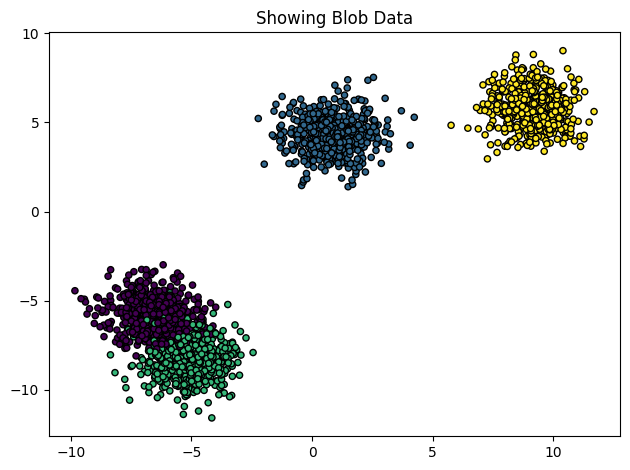

In [13]:
from sklearn.datasets import make_blobs, make_circles
import matplotlib.pyplot as plt

data = make_blobs(n_samples=2000, centers=4)

plt.scatter(data[0][:, 0], data[0][:, 1], c=data[1], edgecolors='k', cmap='viridis', s=20)
plt.title("Showing Blob Data")
plt.tight_layout()
plt.show()

### Moon data

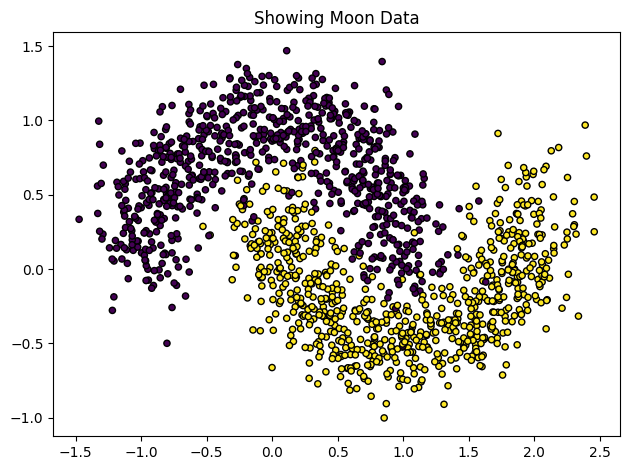

In [14]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


data = make_moons(n_samples=1500, noise=0.2, random_state=44)

plt.scatter(data[0][:, 0], data[0][:, 1], c=data[1], edgecolors='k', cmap='viridis', s=20)
plt.title("Showing Moon Data")
plt.tight_layout()
plt.show()

###  make_classification Data

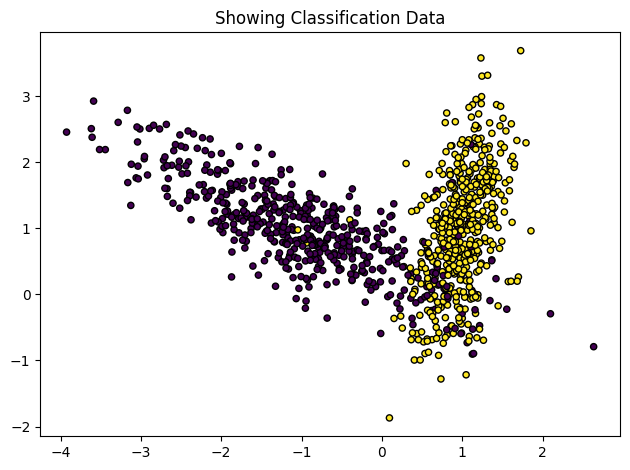

In [15]:
# create data using make_classification and plot it
from sklearn.datasets import make_classification
data = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1)
plt.scatter(data[0][:, 0], data[0][:, 1], c=data[1], edgecolors='k', cmap='viridis', s=20)
plt.title("Showing Classification Data")
plt.tight_layout()
plt.show()

### XOR Blobs

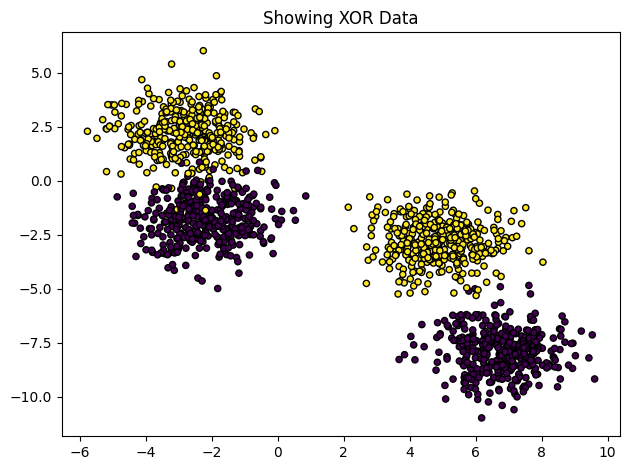

In [16]:
# Create XOR using blobs and plot it
from sklearn.datasets import make_blobs
import numpy as np
data = make_blobs(n_samples=1500, centers=4, random_state=44)
y = np.where(data[1] == 0, 0, np.where(data[1] == 1, 1, np.where(data[1] == 2, 1, 0)))
plt.scatter(data[0][:, 0], data[0][:, 1], c=y, edgecolors='k', cmap='viridis', s=20)
plt.title("Showing XOR Data")
plt.tight_layout()
plt.show()

## Data Splitting

In [17]:
from sklearn.model_selection import train_test_split

# When Training on XOR data, we need to use the y variable we created above, not the original labels from make_blobs
y = data[1]  #--- IGNORE ---
X_train, X_test, y_train, y_test = train_test_split(data[0], y, test_size=0.2, random_state=44)


## Pipeline

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

clf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', 'passthrough'),
    ('model', 'passthrough')
])

clf_pipe.fit(X_train, y_train)

X_test_scaled = clf_pipe.named_steps['scaler'].transform(X_test)

## Evaulation Function: Confusion Matrix and Classification report 

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, log_loss, roc_auc_score

def evaluate_model(clf_pipe, X_test, y_test):
    y_pred = clf_pipe.predict(X_test)
    y_prob = clf_pipe.predict_proba(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)
    
    try:
        if y_prob.shape[1] > 2: # Multiclass
            print(f"ROC-AUC (OVR): {roc_auc_score(y_test, y_prob, multi_class='ovr'):.4f}")
            print(f"Log Loss: {log_loss(y_test, y_prob):.4f}")
        else: # Binary
            print(f"ROC-AUC: {roc_auc_score(y_test, y_prob[:, 1]):.4f}")
            print(f"Log Loss: {log_loss(y_test, y_prob[:, 1]):.4f}")
    except Exception as e:
        print(f"Metric Error: {e}")

## Plot Model

In [20]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
def plot_model_decision_boundary(clf_pipe, X_train, y_train):
    fig, ax = plt.subplots(figsize=(8, 6))
    display = DecisionBoundaryDisplay.from_estimator(clf_pipe, X_train, ax=ax, grid_resolution=200, response_method='predict', cmap='viridis', alpha=0.3)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap='viridis', s=20)
    ax.set_title("LDA Decision Boundary on Data")
    plt.tight_layout()
    plt.show()

## Training

### Linear Discriminant Analysis (LDA)

Accuracy of LDA: 0.9733333333333334


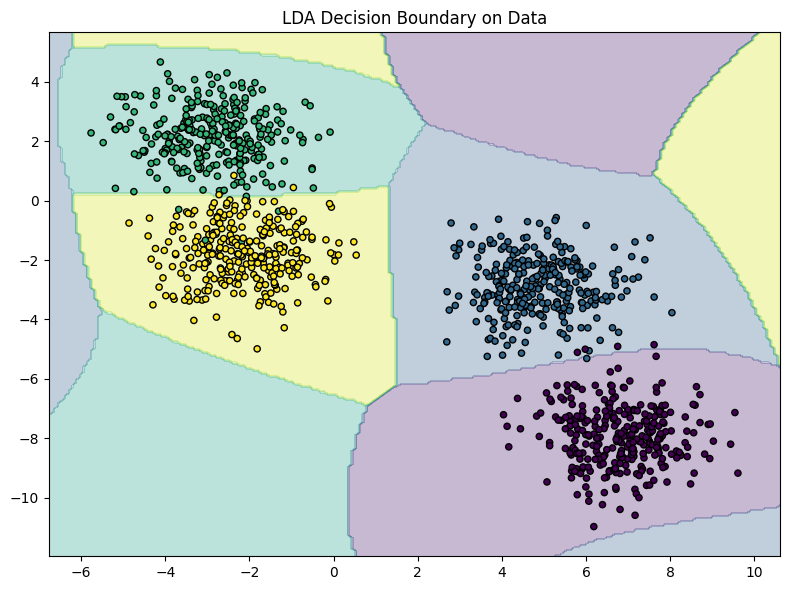

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 65  5]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.93      0.94        70
           3       0.94      0.96      0.95        77

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

ROC-AUC (OVR): 0.9967
Log Loss: 0.3141


In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf_pipe.set_params(poly=PolynomialFeatures(degree=4), model=LinearDiscriminantAnalysis())
clf_pipe.fit(X_train, y_train)

y_pred_lda = clf_pipe.predict(X_test)
print(f"Accuracy of LDA: {clf_pipe.score(X_test, y_test)}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### SVC (Support Vector Classifier)

SVM Accuracy on Data: 0.9767


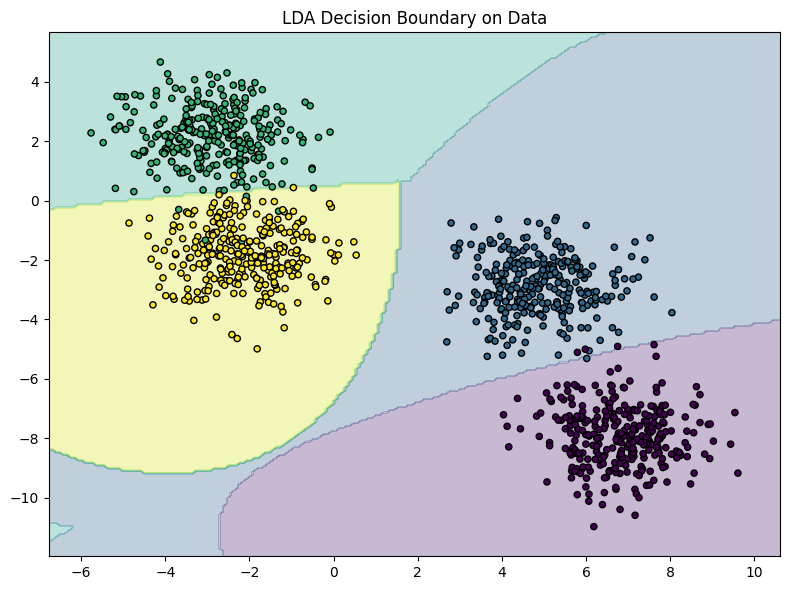

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=44)

clf_pipe.set_params(poly='passthrough', model=svm)

clf_pipe.fit(X_train, y_train)
svm_pred = clf_pipe.predict(X_test)
print(f"SVM Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")

plot_model_decision_boundary(clf_pipe, X_train, y_train)

### Naive bayes

Gaussian Naive Bayes Accuracy on Data: 0.9800


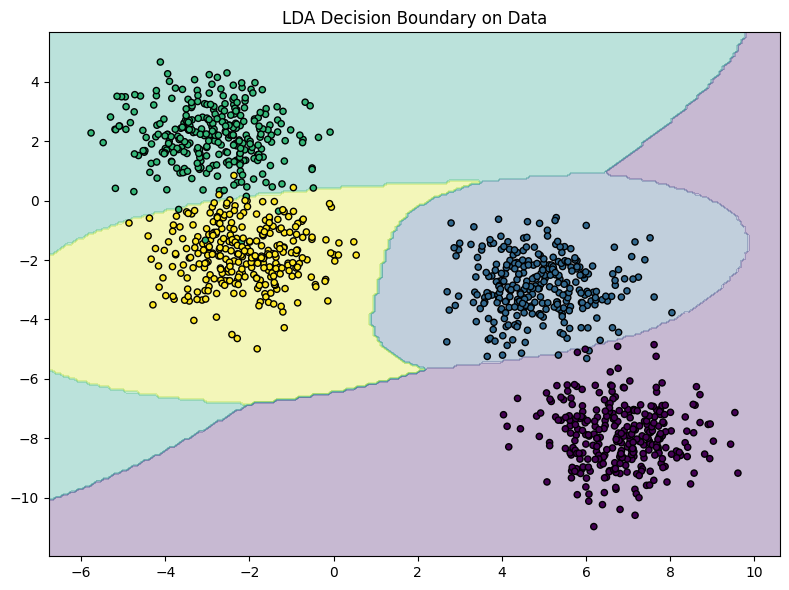

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 67  3]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.96      0.96        70
           3       0.96      0.96      0.96        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9990
Log Loss: 0.1457


In [23]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

clf_pipe.set_params(poly=PolynomialFeatures(degree=2), model=gnb)
clf_pipe.fit(X_train, y_train)
print(f"Gaussian Naive Bayes Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)


### Decisoin Trees

Decision Tree Accuracy on Data: 0.9733


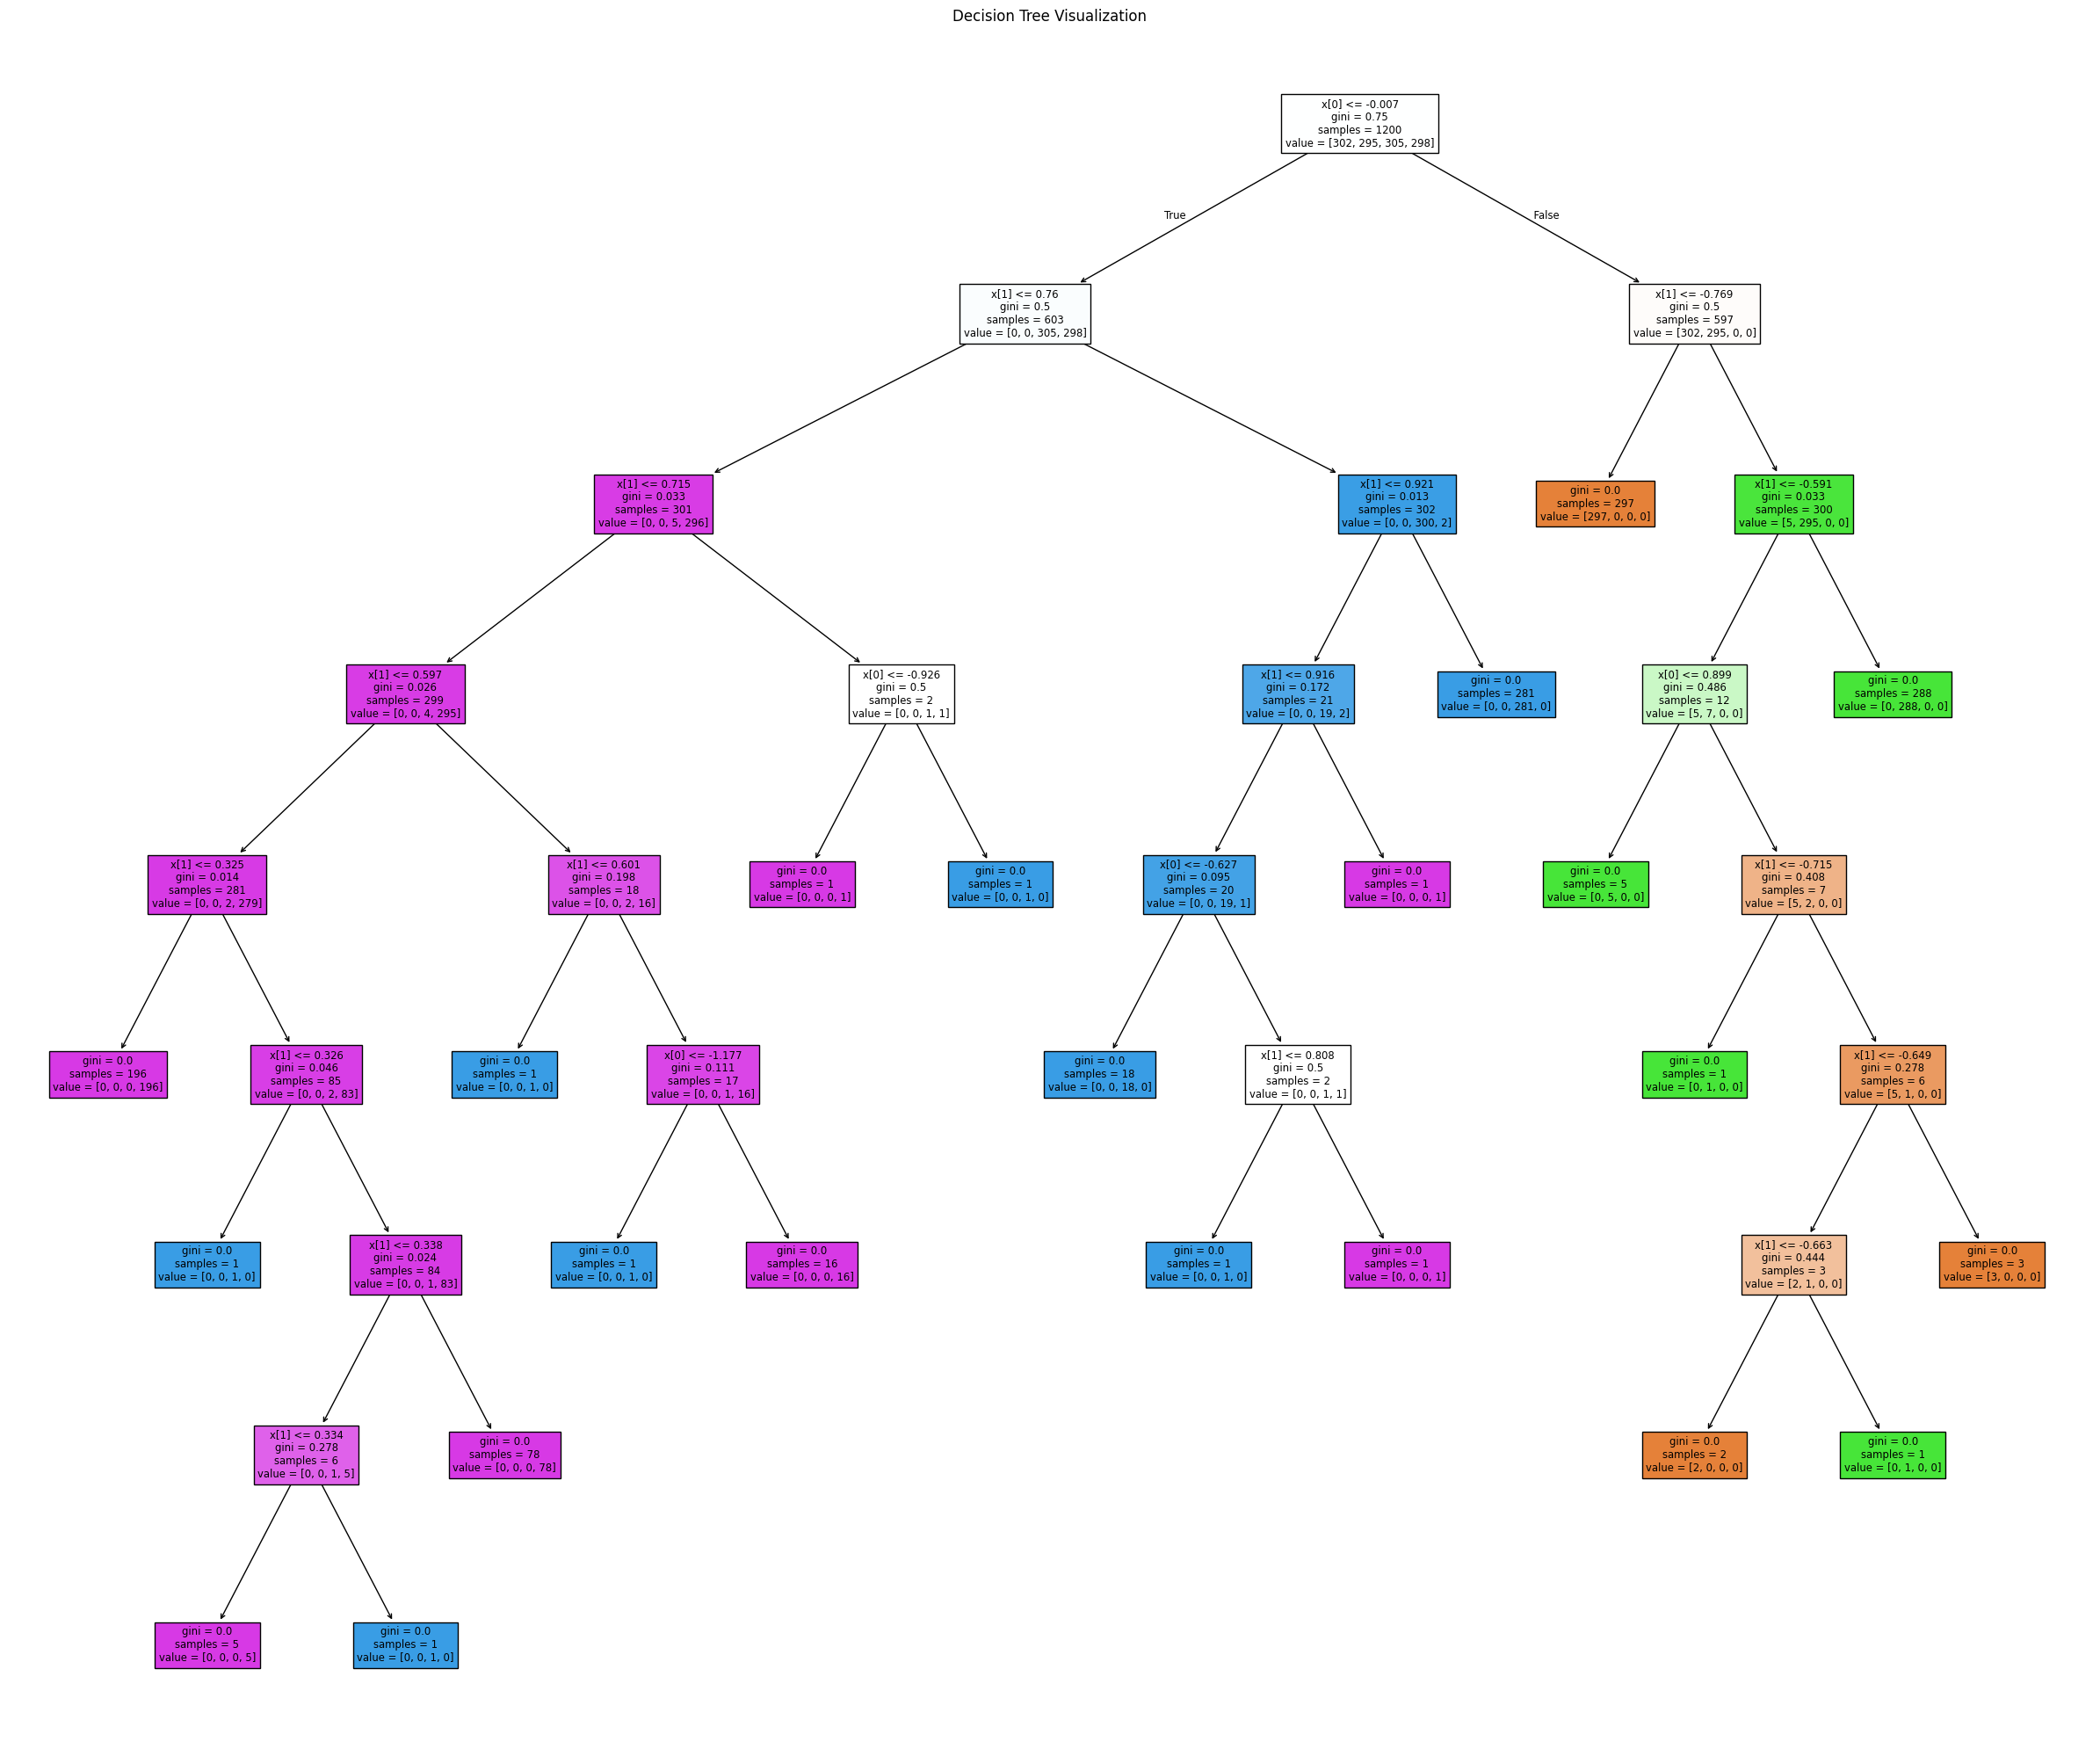

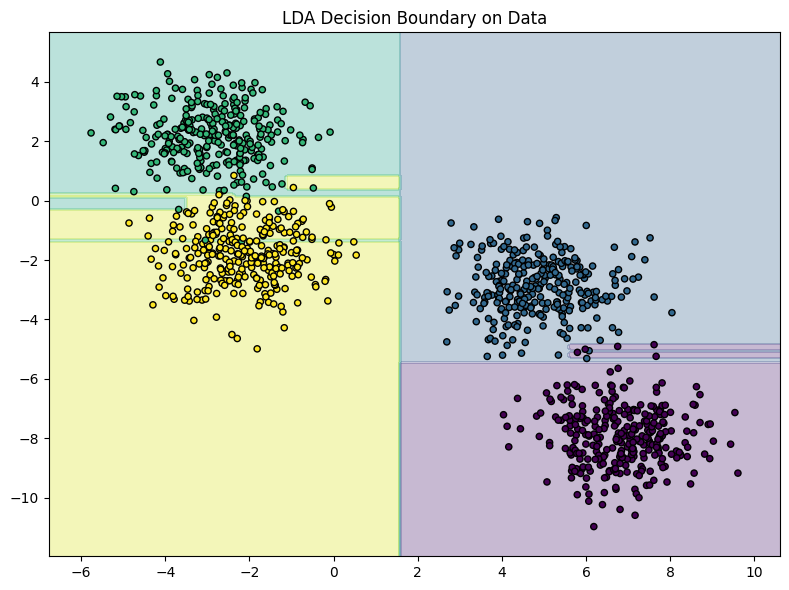

Confusion Matrix:
[[73  0  0  0]
 [ 1 79  0  0]
 [ 0  0 67  3]
 [ 0  0  4 73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        73
           1       1.00      0.99      0.99        80
           2       0.94      0.96      0.95        70
           3       0.96      0.95      0.95        77

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

ROC-AUC (OVR): 0.9822
Log Loss: 0.9612


In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dtc = DecisionTreeClassifier(random_state=44)
clf_pipe.set_params(poly='passthrough', model=dtc)
clf_pipe.fit(X_train, y_train)
print(f"Decision Tree Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")

plt.figure(figsize=(24,20))
plot_tree(dtc, filled=True)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Random Forests

Random Forest Accuracy on Data: 0.9800


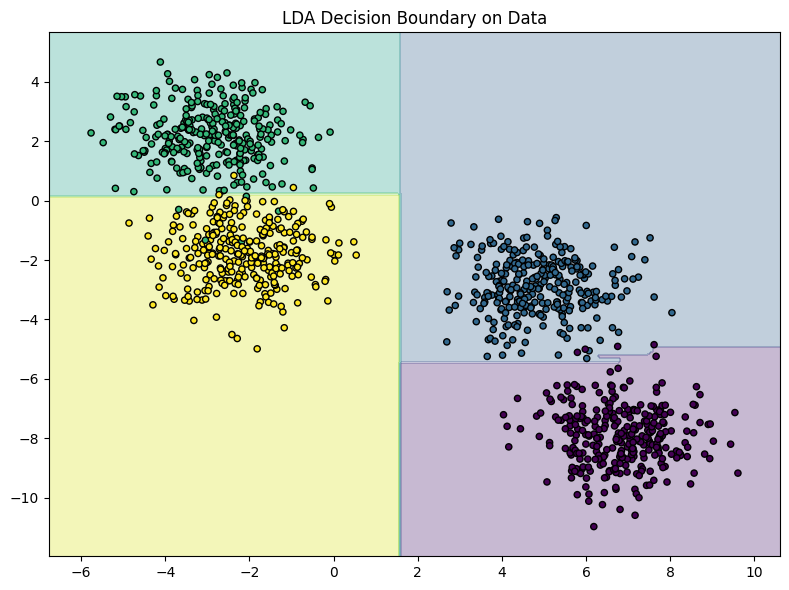

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 67  3]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.96      0.96        70
           3       0.96      0.96      0.96        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9965
Log Loss: 0.1535


In [25]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=44, max_depth=3)
clf_pipe.set_params(poly='passthrough', model=rfc)
clf_pipe.fit(X_train, y_train)
print(f"Random Forest Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Gradient Boosted Machines (GBMs)

Gradient Boosting Accuracy on Data: 0.9733


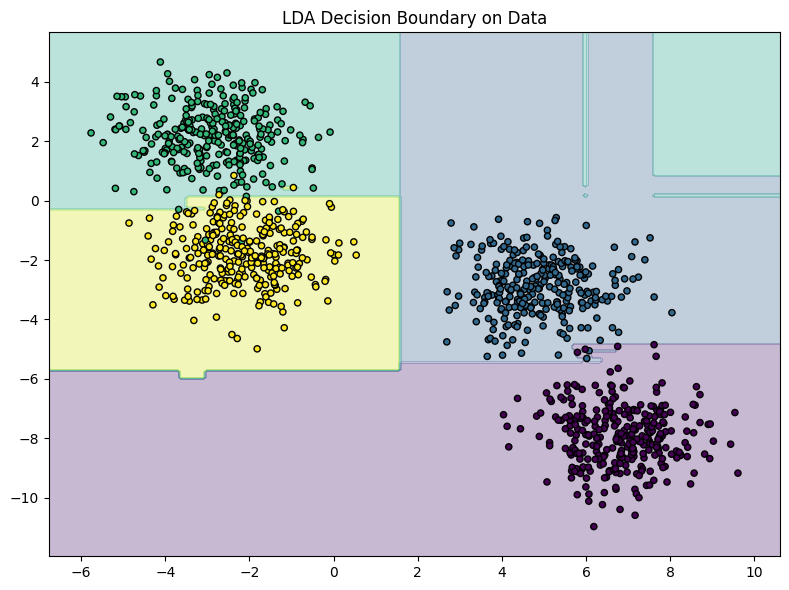

Confusion Matrix:
[[73  0  0  0]
 [ 1 79  0  0]
 [ 0  0 67  3]
 [ 0  0  4 73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        73
           1       1.00      0.99      0.99        80
           2       0.94      0.96      0.95        70
           3       0.96      0.95      0.95        77

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

ROC-AUC (OVR): 0.9968
Log Loss: 0.1482


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators=100, random_state=44, max_depth=3)
clf_pipe.set_params(poly='passthrough', model=gbc)
clf_pipe.fit(X_train, y_train)
print(f"Gradient Boosting Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)


### Logistic Regression

Logistic Regression Accuracy on Data: 0.9800


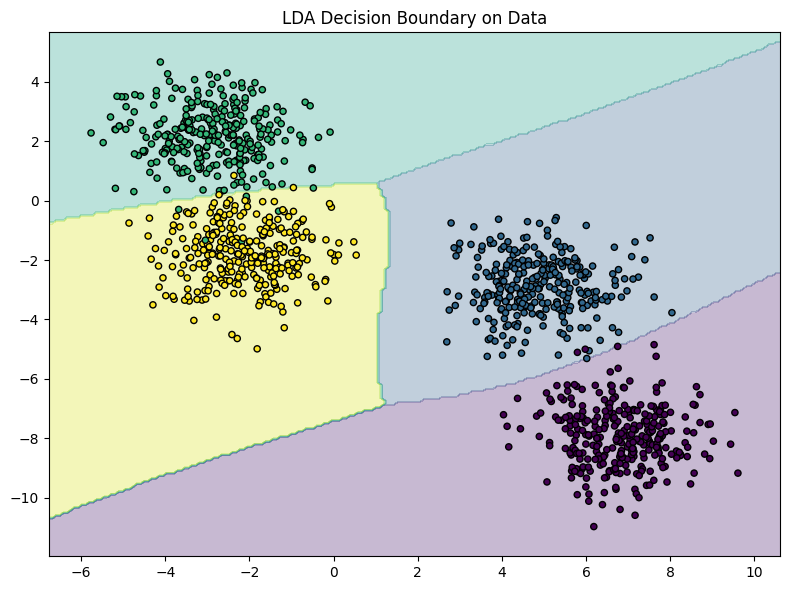

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 66  4]
 [ 0  0  2 75]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.97      0.94      0.96        70
           3       0.95      0.97      0.96        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9990
Log Loss: 0.0608


In [27]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=44)
clf_pipe.set_params(poly=PolynomialFeatures(degree=4), model=log_reg)
clf_pipe.fit(X_train, y_train)
print(f"Logistic Regression Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

#### K-Nearest Neighbour

KNN Accuracy on Data: 0.9800


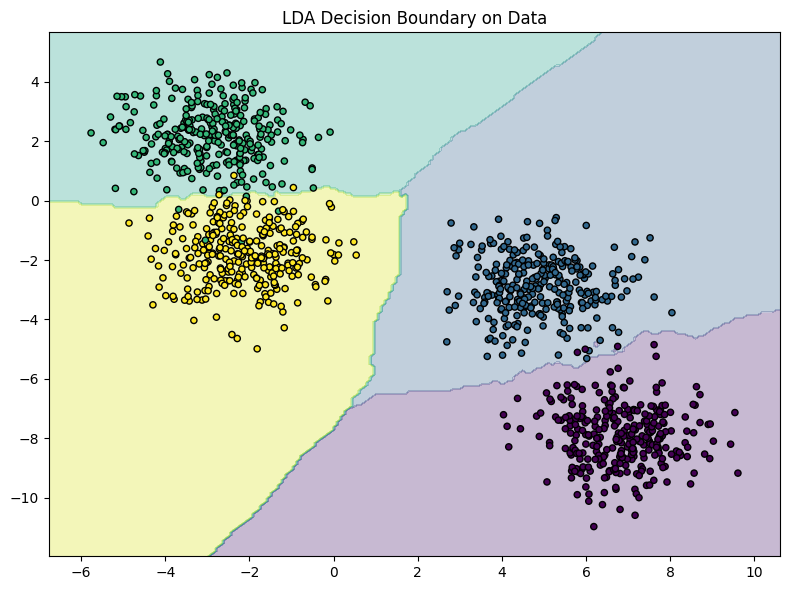

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 67  3]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.96      0.96        70
           3       0.96      0.96      0.96        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9881
Log Loss: 0.6162


In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
clf_pipe.set_params(poly='passthrough', model=knn)
clf_pipe.fit(X_train, y_train)
print(f"KNN Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Ada Boost

AdaBoost Accuracy on Data: 0.9733


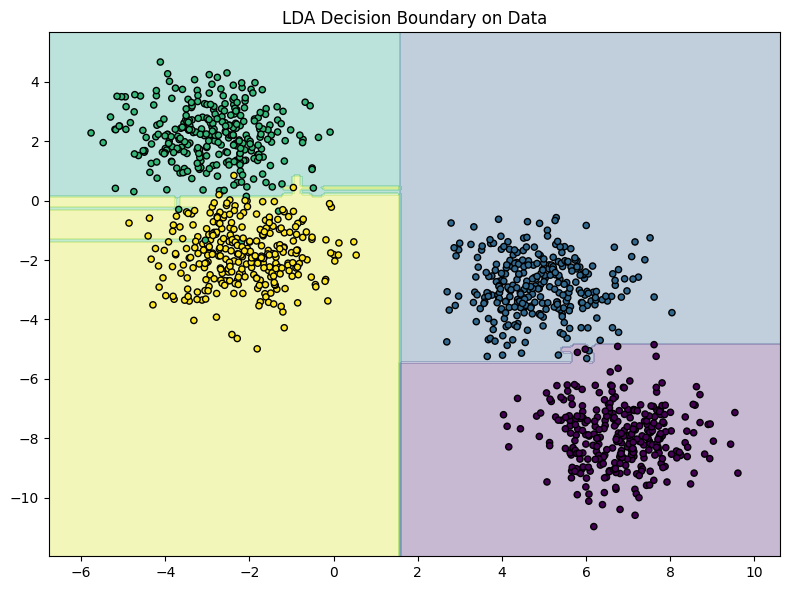

Confusion Matrix:
[[73  0  0  0]
 [ 1 79  0  0]
 [ 0  0 67  3]
 [ 0  0  4 73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        73
           1       1.00      0.99      0.99        80
           2       0.94      0.96      0.95        70
           3       0.96      0.95      0.95        77

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

ROC-AUC (OVR): 0.9976
Log Loss: 1.2446


In [29]:
from sklearn.ensemble import AdaBoostClassifier
base_model = DecisionTreeClassifier(max_depth=2) # Using a simple decision tree as the base estimator for AdaBoost instead of decision stumps
ada_boost = AdaBoostClassifier(n_estimators=100, estimator=base_model, random_state=44)
clf_pipe.set_params(poly='passthrough', model=ada_boost)
clf_pipe.fit(X_train, y_train)
print(f"AdaBoost Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Multi layer Perceptron

MLP Accuracy on Data: 0.9800


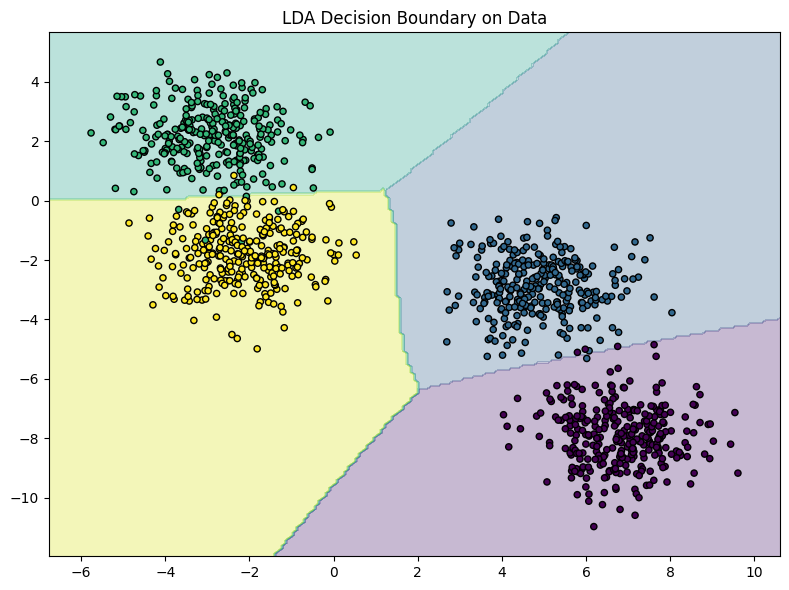

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 67  3]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.96      0.96        70
           3       0.96      0.96      0.96        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9991
Log Loss: 0.0523


In [30]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=44)
clf_pipe.set_params(poly='passthrough', model=mlp)
clf_pipe.fit(X_train, y_train)
print(f"MLP Accuracy on Data: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Quadratic Discriminant Analysis (QDA) - (Representing GDA)

QDA Accuracy: 0.9767


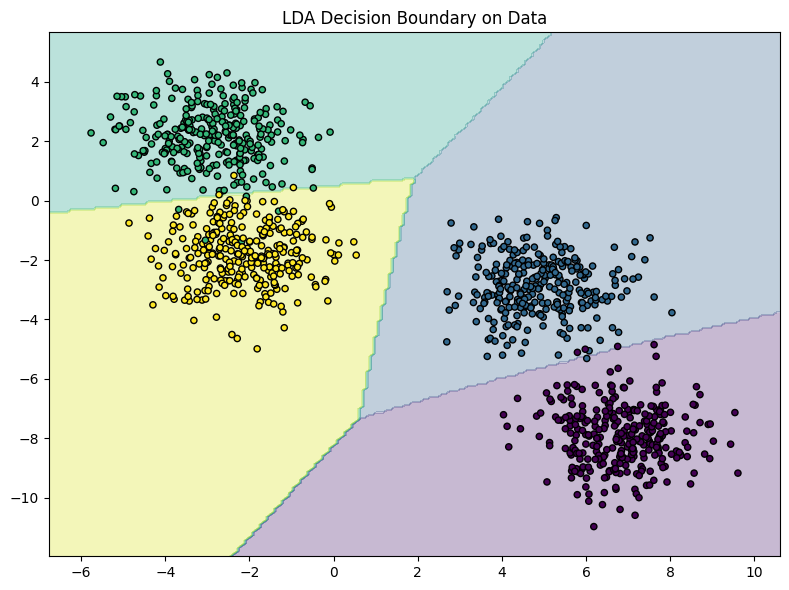

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 66  4]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.94      0.95        70
           3       0.95      0.96      0.95        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9992
Log Loss: 0.0504


In [31]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

clf_pipe.set_params(poly='passthrough', model=QuadraticDiscriminantAnalysis())
clf_pipe.fit(X_train, y_train)
print(f"QDA Accuracy: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### SVM Kernel Comparison (Linear vs. Polynomial vs. RBF)

--- SVM Linear Kernel ---


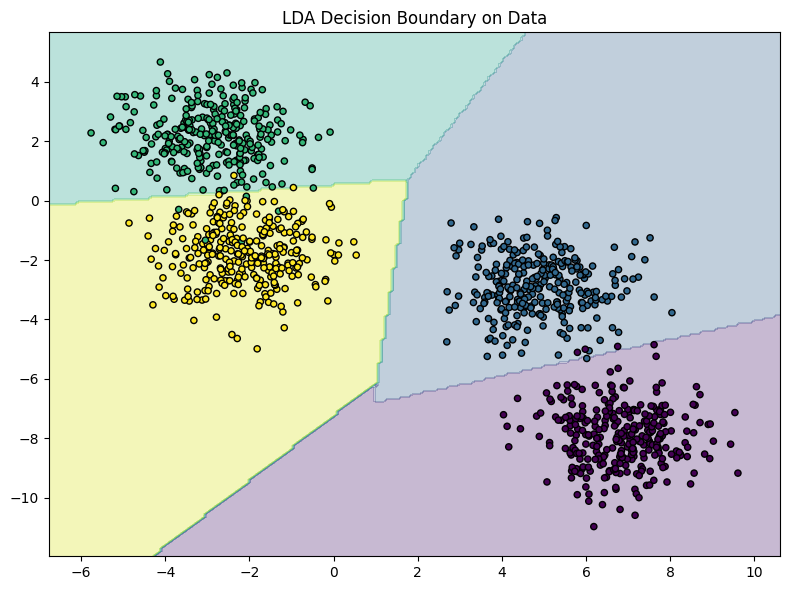

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 66  4]
 [ 0  0  3 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        80
           2       0.96      0.94      0.95        70
           3       0.95      0.96      0.95        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9992
Log Loss: 0.0573


In [32]:
from sklearn.svm import SVC

print("--- SVM Linear Kernel ---")
clf_pipe.set_params(model=SVC(kernel='linear', probability=True))
clf_pipe.fit(X_train, y_train)
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

--- SVM Polynomial Kernel (Degree 3) ---


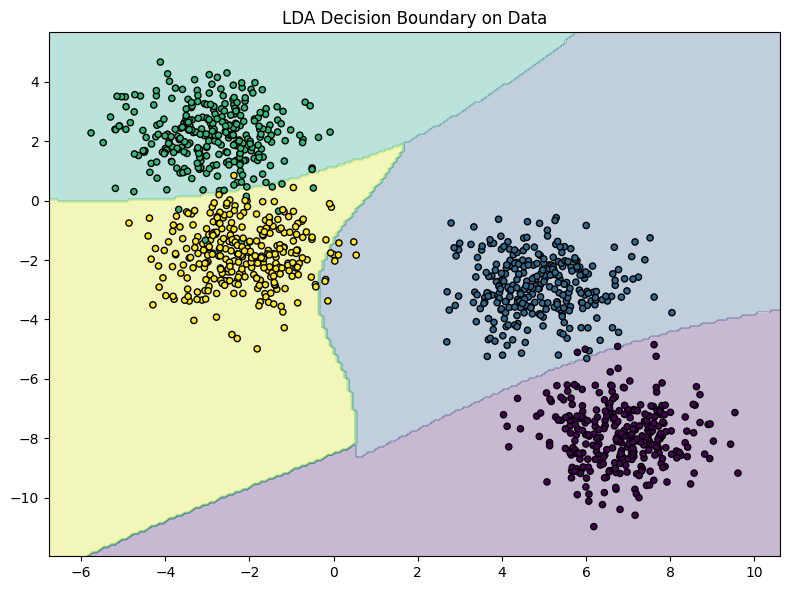

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 66  4]
 [ 0  1  2 74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       0.99      1.00      0.99        80
           2       0.97      0.94      0.96        70
           3       0.95      0.96      0.95        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9987
Log Loss: 0.0742


In [33]:
print("--- SVM Polynomial Kernel (Degree 3) ---")
clf_pipe.set_params(model=SVC(kernel='poly', degree=3, probability=True))
clf_pipe.fit(X_train, y_train)
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)

### Softmax Regression (Multiclass Logistic Regression)

Logistic Regression Accuracy: 0.9767


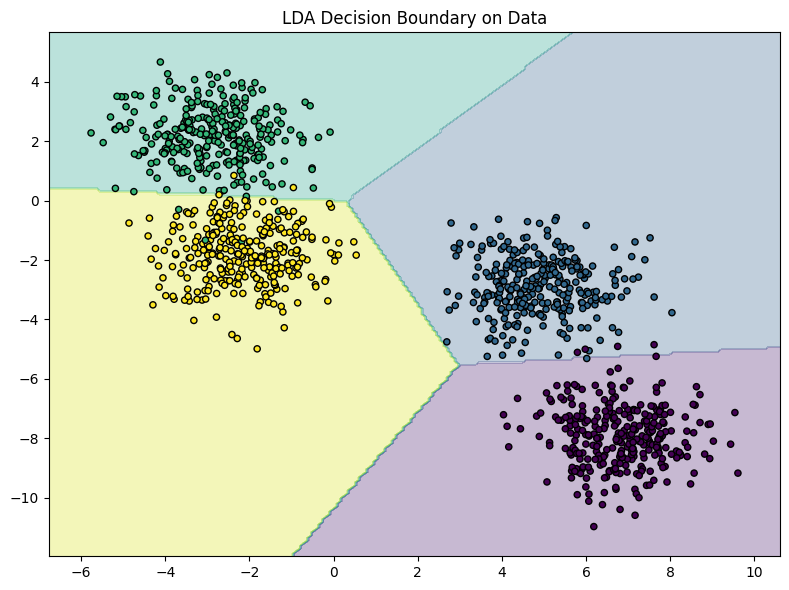

In [49]:
from sklearn.linear_model import LogisticRegression

# Using LogisticRegression for multiclass classification
# Note: This version of scikit-learn does not support multi_class='multinomial' for softmax regression.
# LogisticRegression uses one-vs-rest by default for multiclass.
# To use multinomial, upgrade scikit-learn to 0.20 or later.

clf_pipe.set_params(poly='passthrough', model=LogisticRegression(solver='lbfgs'))
clf_pipe.fit(X_train, y_train)
print(f"Logistic Regression Accuracy: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)

### Elastic Net Classification

Elastic Net Classification Accuracy: 0.9767


d:\Code\ML\Practice Code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


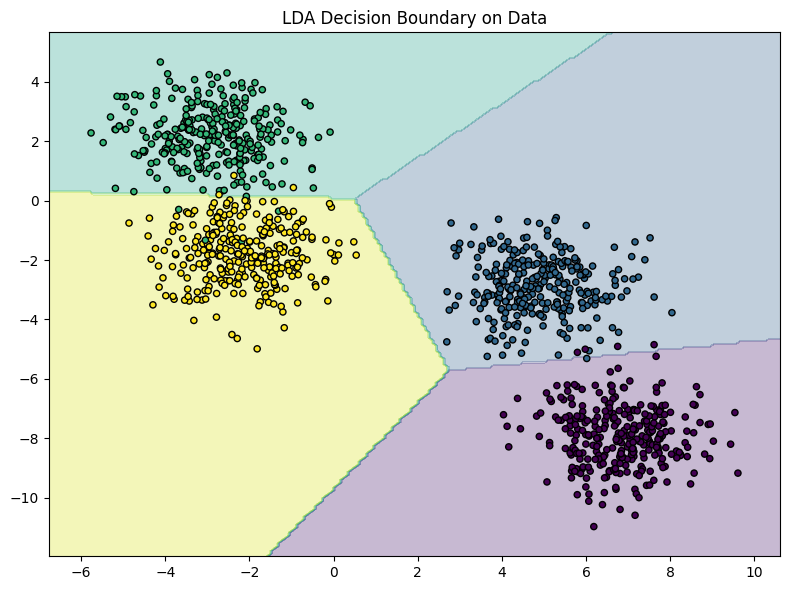

Confusion Matrix:
[[73  0  0  0]
 [ 0 80  0  0]
 [ 0  0 67  3]
 [ 0  1  3 73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       0.99      1.00      0.99        80
           2       0.96      0.96      0.96        70
           3       0.96      0.95      0.95        77

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

ROC-AUC (OVR): 0.9991
Log Loss: 0.0696


In [35]:
from sklearn.linear_model import LogisticRegression

# solver='saga' is required for elasticnet penalty
clf_pipe.set_params(model=LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=10000))
clf_pipe.fit(X_train, y_train)
print(f"Elastic Net Classification Accuracy: {clf_pipe.score(X_test, y_test):.4f}")
plot_model_decision_boundary(clf_pipe, X_train, y_train)
evaluate_model(clf_pipe, X_test, y_test)